In [109]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt

from wildlife_tools.data import FeatureDataset

In [69]:
root_dir = "/media/filming/2025-白海豚/20240825-JM_02-1/"
features = FeatureDataset.from_file(root_dir + "/FIN_DEEPPFEATUES_SELECTED_MERGED_PAIRED_SOCIAL")
METAINFO_csv = root_dir + "/FIN_METAINFO.csv"
full_metainfo = pd.read_csv(METAINFO_csv, index_col=0)

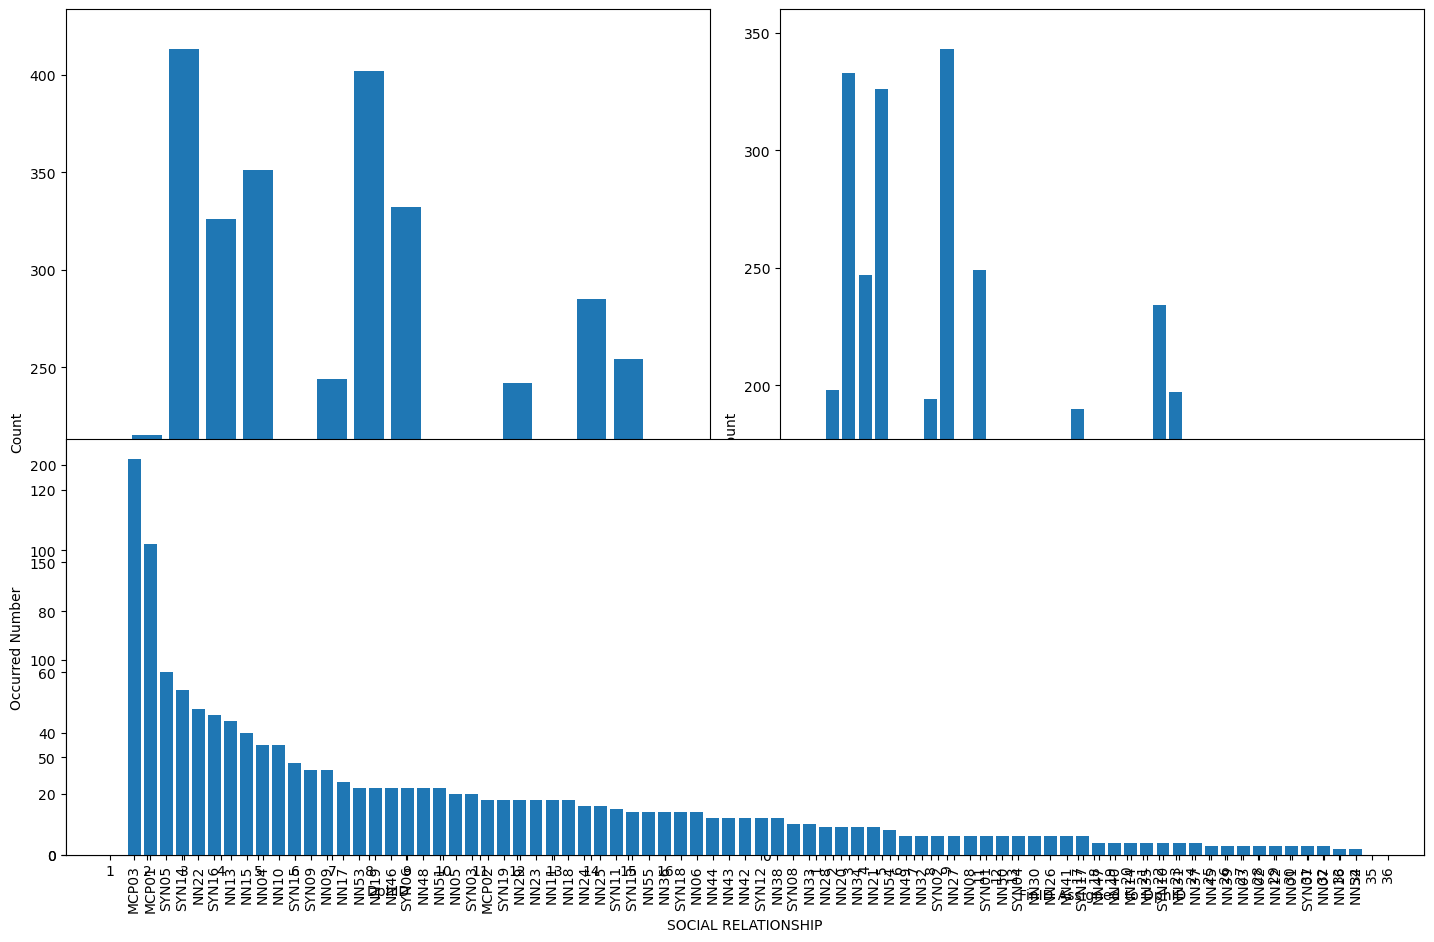

In [31]:
# Plot Statistics
plt.figure(figsize=(15, 10))
DphID_hist  = features.metadata.DphID.value_counts()
plt.subplot(1, 2, 1)
plt.bar(DphID_hist.index.values+1, DphID_hist.values)
plt.xticks(DphID_hist.index.values+1) 
plt.xlabel("DphID")
plt.ylabel("Count")
plt.subplot(1, 2, 2)
FinID_hist = features.metadata.FinID2.value_counts()
plt.bar(FinID_hist.index.values + 1, FinID_hist.values)
plt.xticks(FinID_hist.index.values+1, rotation=90) 
plt.xlabel("FinID Assigned to DphID")
plt.ylabel("Count")

plt.subplot(2, 1, 2)
relationship_hist  = features.metadata.confirmed_group.value_counts()
plt.bar(relationship_hist.index.values[1:], relationship_hist.values[1:])
plt.xticks(relationship_hist.index.values[1:], rotation=90) 
plt.xlabel("SOCIAL RELATIONSHIP")
plt.ylabel("Occurred Number")
plt.tight_layout()

plt.savefig(root_dir + "FIN_STASTISTICS_SUMMARY.png")

In [125]:
root_dir.split("/")[-2]

'20240825-JM_02-1'

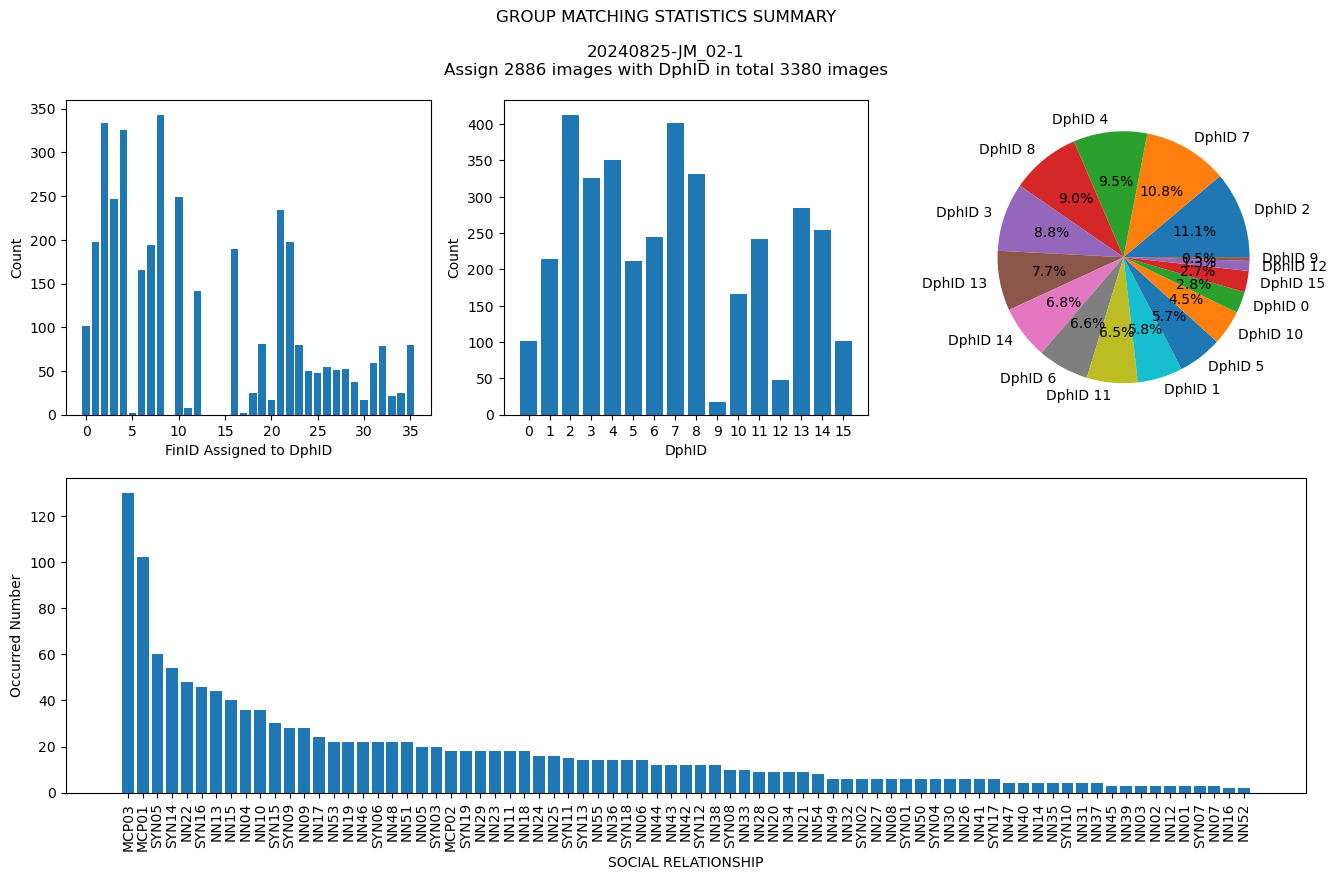

In [134]:
# Plot Statistics
FinID_hist = features.metadata.FinID2.value_counts()
DphID_hist  = features.metadata.DphID.value_counts()
relationship_hist  = features.metadata.confirmed_group.value_counts()
captureability = features.metadata.DphID.value_counts()
DphID_list = [ "DphID %d"%id for id in captureability.index.values]

orignal_image_number = len(full_metainfo.orig_img.unique())
has_dphid_image_number = len(features.metadata.orig_img[features.metadata.DphID!=0].unique())

fig, axd = plt.subplot_mosaic(
    [["FinID", "DphID", "Captureablity"],
     ["Social","Social", "Social"]],
    #layout="constrained",
    figsize=(16, 9)
)
fig.suptitle("GROUP MATCHING STATISTICS SUMMARY\n\n"
             + "%s\n"%(root_dir.split("/")[-2])
             + "Assign %d images with DphID in total %d images"%(has_dphid_image_number, orignal_image_number)
            )

# Plot Fin ID Histogram
axd["FinID"].bar(FinID_hist.index.values , FinID_hist.values)
#axd["FinID"].set_xticks(FinID_hist.index.values, labels=FinID_hist.index.values, rotation=45) 
axd["FinID"].set_xlabel("FinID Assigned to DphID")
axd["FinID"].set_ylabel("Count")
# Plot Dph ID Histogram
axd["DphID"].bar(DphID_hist.index.values, DphID_hist.values)
axd["DphID"].set_xticks(DphID_hist.index.values) 
axd["DphID"].set_xlabel("DphID")
axd["DphID"].set_ylabel("Count")
# Plot Captureablity
axd["Captureablity"].pie(captureability.values, labels = DphID_list, autopct='%1.1f%%');

# Plot Soical Relationship
axd["Social"].bar(relationship_hist.index.values[1:], relationship_hist.values[1:])
axd["Social"].set_xticks(relationship_hist.index.values[1:], rotation=90, labels=relationship_hist.index.values[1:]) 
axd["Social"].set_xlabel("SOCIAL RELATIONSHIP")
axd["Social"].set_ylabel("Occurred Number")

plt.savefig(root_dir + "FIN_STASTISTICS_SUMMARY.pdf")